# Escalamiento

|                |                  |
:----------------|------------------|
| **Nombre**     | Omar Mendoza     |
| **Fecha**      | 31/08/2026       |
| **Expediente** | 757806           |

## Desplazamiento

Regresiones de orden 1 para los archivos bateria_tableta.txt y
Salarios_minimos.csv, escalamiento para evitar overflow

## Salarios mínimos

In [1]:
# Leer archivo Salarios_minimos.csv
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

import numpy as np


datos2 = pd.read_csv("Salarios_minimos.csv")

print(datos2)

    Periodo  Salario
0   1988.25     8.00
1   1989.00     8.64
2   1989.50     9.16
3   1990.00    10.08
4   1990.84    11.90
5   1991.84    13.33
6   1993.00    14.27
7   1994.00    15.27
8   1995.00    16.34
9   1995.30    18.30
10  1996.00    20.15
11  1996.30    22.60
12  1997.00    26.45
13  1998.00    30.20
14  1999.00    34.45
15  2000.00    37.90
16  2001.00    40.35
17  2002.00    42.15
18  2003.00    43.65
19  2004.00    45.24
20  2005.00    46.80
21  2006.00    48.67
22  2007.00    50.57
23  2008.00    52.59
24  2009.00    54.80
25  2010.00    57.46
26  2011.00    59.82
27  2012.00    62.33
28  2013.00    64.76
29  2014.00    67.29
30  2015.00    70.10
31  2016.00    73.04
32  2017.00    80.04
33  2018.00    88.36


In [2]:
datos2.shape # Renglones y columnas

(34, 2)

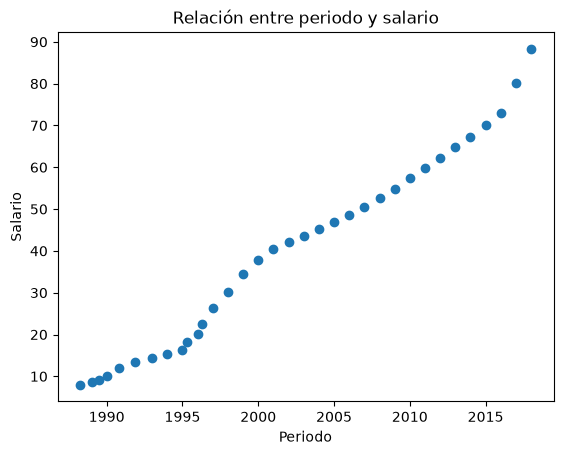

In [3]:
plt.scatter(datos2['Periodo'], datos2['Salario'])
plt.xlabel('Periodo')
plt.ylabel('Salario')
plt.title('Relación entre periodo y salario')
plt.show()

Al periodo hay que restarle 1988 antes de sacar las potencias. Si se deja el año
tal cual 2000 elevado a la novena da un número enorme y la regresión sale mal. El
orden 5 queda en 0.9857546631343813 y el orden 9 en 0.9857920242932819. Es casi
igual que la recta

In [4]:
X_v2 = np.reshape(datos2['Periodo'].values - 1988, (-1, 1))
y2 = datos2['Salario'].values

In [5]:
X1_2 = X_v2



In [6]:
lr1_2 = LinearRegression()
lr1_2.fit(X1_2, y2)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.53]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.716
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[52.38]


In [7]:
lr1_2.intercept_ # Intercepto, B0

np.float64(3.715577808507632)

In [8]:
lr1_2.coef_ # B1

array([2.52832885])

El modelo de orden 1 queda como 3.715577808507632 + 2.528328847811839x donde x es
el periodo menos 1988

In [9]:
print("Orden 1:", lr1_2.score(X1_2, y2))


Orden 1: 0.9844566663095193


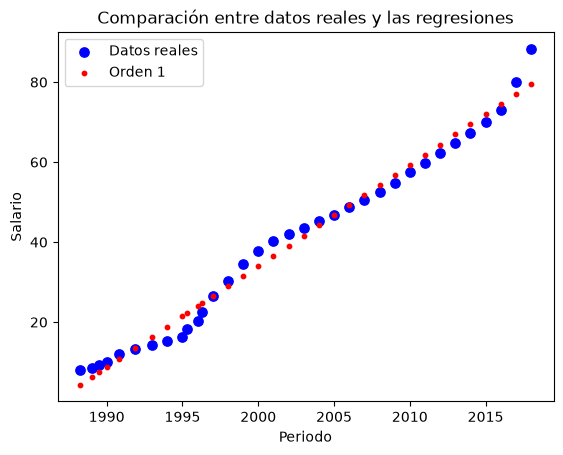

In [10]:
plt.scatter(datos2['Periodo'], y2, s=45, color='blue', label='Datos reales')
plt.scatter(datos2['Periodo'], lr1_2.predict(X1_2), s=10, color='red', label='Orden 1')

plt.xlabel('Periodo')
plt.ylabel('Salario')
plt.title('Comparación entre datos reales y las regresiones')
plt.legend()
plt.show()

El salario sube cada vez más rápido y por eso la recta no le atina. Queda abajo
de los puntos al principio y al final y arriba en la parte de en medio. Los de
orden 5 y 9 siguen mejor la subida

In [11]:
#ERROR


## ESCALAMIENTO

Ejercicio de la bateria

In [12]:
# Leer archivo bateria_tableta.txt como csv

import pandas as pd

datos = pd.read_csv("bateria_tableta.txt")

print(datos)

    carga  duracion
0    2.81      5.62
1    7.14      8.00
2    2.72      5.44
3    3.87      7.74
4    1.90      3.80
..    ...       ...
95   4.38      8.00
96   8.06      8.00
97   8.05      8.00
98   1.10      2.20
99   6.65      8.00

[100 rows x 2 columns]


In [13]:
datos.describe()

,carga,duracion
count,100.000000,100.000000
mean,4.573000,6.206800
std,2.788603,2.454116
min,0.000000,0.000000
25%,1.987500,3.975000
50%,4.375000,8.000000
75%,6.522500,8.000000
max,11.720000,8.000000


In [14]:
datos.shape # Renglones y columnas


(100, 2)

### Escalamiento a dominio (1, 2)

En lugar de nada mas restar, se escala el dominio a (1, 2) con
x_esc = 1 + (x - min) / (max - min). Es una transformacion lineal, entonces la
regresion tiene que dar lo mismo que antes de cambiar el dominio

In [15]:
import numpy as np

X_v = np.reshape(datos['carga'].values, (-1, 1))
y = datos['duracion'].values

xmin = datos['carga'].min()
xmax = datos['carga'].max()

print("Dominio original:", xmin, xmax)

Dominio original: 0.0 11.72


In [16]:
# Escalamiento de la carga al dominio 1 a 2

carga_esc = 1 + (datos['carga'] - xmin) / (xmax - xmin)

X_v_esc = np.reshape(carga_esc.values, (-1, 1))

print("Dominio escalado:", carga_esc.min(), carga_esc.max())

Dominio escalado: 1.0 2.0


In [ ]:
# Matriz de orden 9 para los dos dominios

X9 = np.hstack([X_v, X_v**2, X_v**3, X_v**4, X_v**5,
                X_v**6, X_v**7, X_v**8, X_v**9])

X9_esc = np.hstack([X_v_esc, X_v_esc**2, X_v_esc**3, X_v_esc**4, X_v_esc**5,
                    X_v_esc**6, X_v_esc**7, X_v_esc**8, X_v_esc**9])

In [18]:
from sklearn.linear_model import LinearRegression

lr9 = LinearRegression()
lr9.fit(X9, y)

lr9_esc = LinearRegression()
lr9_esc.fit(X9_esc, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-38.78,-27.49, 9.99,...,-46.4 , 39.11, -8.13]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,25.34
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[859.59, 47.15, 3.75,..., 0. , 0. , 0. ]"


In [19]:
print("Orden 9 dominio (0, 11.72):", lr9.score(X9, y))
print("Orden 9 dominio (1, 2)    :", lr9_esc.score(X9_esc, y))

Orden 9 dominio (0, 11.72): 0.6599786049223085
Orden 9 dominio (1, 2)    : 0.9924685766553699


In [20]:
print("Coeficientes dominio original:")
print(lr9.intercept_)
print(lr9.coef_)
print()
print("Coeficientes dominio escalado:")
print(lr9_esc.intercept_)
print(lr9_esc.coef_)

Coeficientes dominio original:
3.937206868708911
[ 1.96215281e-06  1.18357228e-05  5.63133538e-05  2.27505603e-04
  7.30461439e-04  1.42491439e-03 -4.83193244e-04  5.07961750e-05
 -1.74034242e-06]

Coeficientes dominio escalado:
25.339432620960523
[-38.7778695  -27.49035908   9.98557454  39.02008643  28.38556741
 -21.14924722 -46.4044648   39.11470934  -8.12990227]


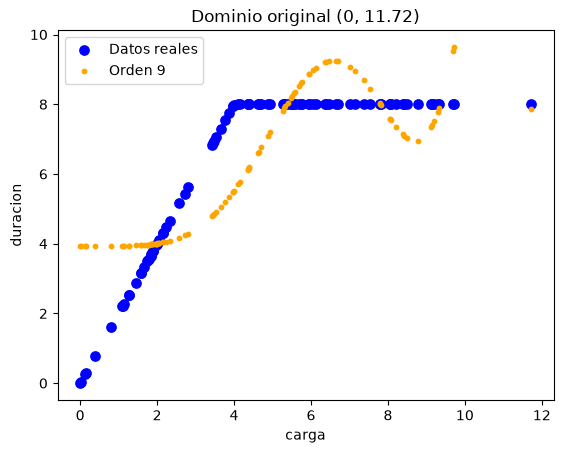

In [21]:
plt.scatter(X_v, y, s=45, color='blue', label='Datos reales')
plt.scatter(X_v, lr9.predict(X9), s=10, color='orange', label='Orden 9')
plt.xlabel('carga')
plt.ylabel('duracion')
plt.title('Dominio original (0, 11.72)')
plt.legend()
plt.show()

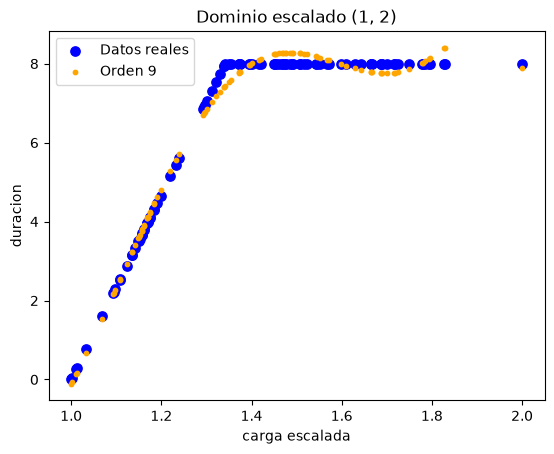

In [22]:
plt.scatter(X_v_esc, y, s=45, color='blue', label='Datos reales')
plt.scatter(X_v_esc, lr9_esc.predict(X9_esc), s=10, color='orange', label='Orden 9')
plt.xlabel('carga escalada')
plt.ylabel('duracion')
plt.title('Dominio escalado (1, 2)')
plt.legend()
plt.show()

Las dos graficas son la misma curva, nada mas con el eje x comprimido de (0, 11.72)
a (1, 2)

### Salarios minimos con dominio (1, 2)

In [23]:
y2 = datos2['Salario'].values

pmin = datos2['Periodo'].min()
pmax = datos2['Periodo'].max()

print("Dominio original:", pmin, pmax)

Dominio original: 1988.25 2018.0


In [24]:
# Escalamiento del periodo al dominio 1 a 2

periodo_esc = 1 + (datos2['Periodo'] - pmin) / (pmax - pmin)

X_v2_esc = np.reshape(periodo_esc.values, (-1, 1))

print("Dominio escalado:", periodo_esc.min(), periodo_esc.max())

Dominio escalado: 1.0 2.0


In [25]:
# Matriz de orden 9 con el periodo menos 1988 y con el periodo escalado

X9_2 = np.hstack([X_v2, X_v2**2, X_v2**3, X_v2**4, X_v2**5,
                  X_v2**6, X_v2**7, X_v2**8, X_v2**9])

X9_2_esc = np.hstack([X_v2_esc, X_v2_esc**2, X_v2_esc**3, X_v2_esc**4, X_v2_esc**5,
                      X_v2_esc**6, X_v2_esc**7, X_v2_esc**8, X_v2_esc**9])

lr9_2 = LinearRegression()
lr9_2.fit(X9_2, y2)

lr9_2_esc = LinearRegression()
lr9_2_esc.fit(X9_2_esc, y2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-214.06,-188.95, -14.17,...,-201. , 133.96, -24. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,243.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[924.47, 33.75, 2.47,..., 0. , 0. , 0. ]"


In [26]:
print("Orden 9 con periodo - 1988:", lr9_2.score(X9_2, y2))
print("Orden 9 con dominio (1, 2) :", lr9_2_esc.score(X9_2_esc, y2))

Orden 9 con periodo - 1988: 0.8716949873587378
Orden 9 con dominio (1, 2) : 0.9961481357480592


In [27]:
print("Coeficientes con periodo - 1988:")
print(lr9_2.intercept_)
print(lr9_2.coef_)
print()
print("Coeficientes con dominio (1, 2):")
print(lr9_2_esc.intercept_)
print(lr9_2_esc.coef_)

Coeficientes con periodo - 1988:
21.28209420044839
[ 2.01299096e-14  4.49858368e-13  8.35699792e-12  1.40738708e-10
  2.12414318e-09  2.68110304e-08  2.26734064e-07 -1.54558698e-08
  2.65970414e-10]

Coeficientes con dominio (1, 2):
243.18999634499352
[-214.05908388 -188.94513213  -14.17198586  156.92786088  160.81339452
  -43.60804079 -200.99737651  133.95749415  -24.00458891]


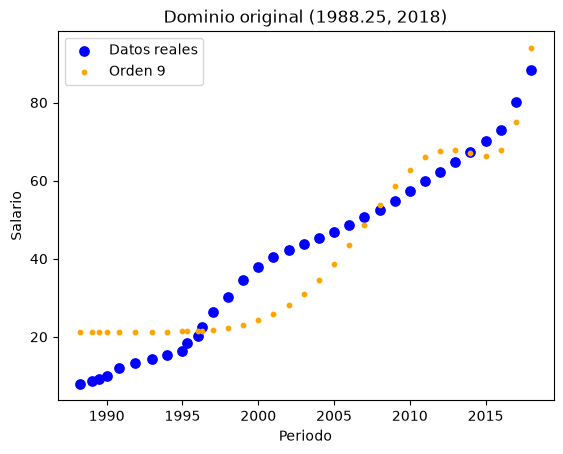

In [28]:
plt.scatter(datos2['Periodo'], y2, s=45, color='blue', label='Datos reales')
plt.scatter(datos2['Periodo'], lr9_2.predict(X9_2), s=10, color='orange', label='Orden 9')
plt.xlabel('Periodo')
plt.ylabel('Salario')
plt.title('Dominio original (1988.25, 2018)')
plt.legend()
plt.show()

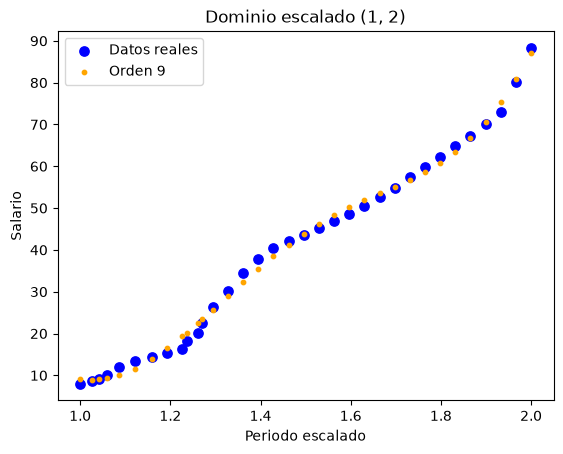

In [29]:
plt.scatter(X_v2_esc, y2, s=45, color='blue', label='Datos reales')
plt.scatter(X_v2_esc, lr9_2_esc.predict(X9_2_esc), s=10, color='orange', label='Orden 9')
plt.xlabel('Periodo escalado')
plt.ylabel('Salario')
plt.title('Dominio escalado (1, 2)')
plt.legend()
plt.show()

### Escalamiento estandar

Se estandariza la carga para que quede con
media 0 y desviacion estandar 1, grado 9

In [30]:
media = datos['carga'].mean()
desv = datos['carga'].std()

print("Media original:", media)
print("Desviacion estandar original:", desv)

Media original: 4.573
Desviacion estandar original: 2.7886025246356


In [31]:
# Estandarizacion de la carga a media 0 y desviacion 1

carga_est = (datos['carga'] - media) / desv

X_v_est = np.reshape(carga_est.values, (-1, 1))

print("Media nueva:", carga_est.mean())
print("Desviacion estandar nueva:", carga_est.std())
print("Dominio nuevo:", carga_est.min(), carga_est.max())

Media nueva: -1.3988810110276973e-16
Desviacion estandar nueva: 1.0
Dominio nuevo: -1.6398895000633251 2.56293248566643


In [32]:
# Matriz de orden 9 con la carga estandarizada

X9_est = np.hstack([X_v_est, X_v_est**2, X_v_est**3, X_v_est**4, X_v_est**5,
                    X_v_est**6, X_v_est**7, X_v_est**8, X_v_est**9])

lr9_est = LinearRegression()
lr9_est.fit(X9_est, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 0.87,-3.83, 2.67,..., 0.51, 0.09,-0.05]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.079
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[5168.54, 162.86, 92.53,..., 1.67, 0.42, 0.24]"


In [33]:
print("Orden 9 dominio (0, 11.72) :", lr9.score(X9, y))
print("Orden 9 dominio (1, 2)     :", lr9_esc.score(X9_esc, y))
print("Orden 9 estandarizado      :", lr9_est.score(X9_est, y))

Orden 9 dominio (0, 11.72) : 0.6599786049223085
Orden 9 dominio (1, 2)     : 0.9924685766553699
Orden 9 estandarizado      : 0.99891267294693


In [34]:
print("Coeficientes estandarizados:")
print(lr9_est.intercept_)
print(lr9_est.coef_)

Coeficientes estandarizados:
8.078921730458617
[ 0.87305015 -3.8335034   2.66564513  2.1427503  -1.77019112 -0.71117705
  0.50914141  0.08629359 -0.05190043]


Aqui el dominio ya no queda en un intervalo fijo, va de -1.64 a 2.56, y depende de que
tan lejos esta cada dato de la media. El R2 sigue siendo el mismo que en los otros dos
escalamientos

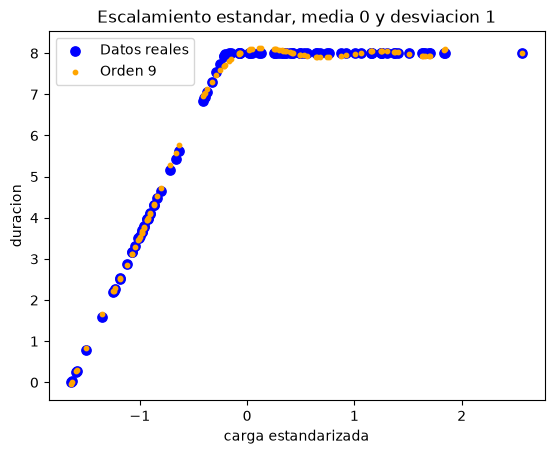

In [35]:
plt.scatter(X_v_est, y, s=45, color='blue', label='Datos reales')
plt.scatter(X_v_est, lr9_est.predict(X9_est), s=10, color='orange', label='Orden 9')
plt.xlabel('carga estandarizada')
plt.ylabel('duracion')
plt.title('Escalamiento estandar, media 0 y desviacion 1')
plt.legend()
plt.show()

### Escalamiento estandar de salarios minimos con StandardScaler

In [44]:
from sklearn.preprocessing import StandardScaler

X_v2_orig = np.reshape(datos2['Periodo'].values, (-1, 1))

scaler = StandardScaler()
scaler.fit(X_v2_orig)

print("Media scaler:", scaler.mean_)
print("Desviacion scaler:", scaler.scale_)



Media scaler: [2002.17735294]
Desviacion scaler: [8.98265365]


In [45]:
X_v2_est = scaler.transform(X_v2_orig)

print("Media nueva:", X_v2_est.mean())
print("Desviacion estandar nueva:", X_v2_est.std())
print("Dominio nuevo:", X_v2_est.min(), X_v2_est.max())

Media nueva: 4.486607164220486e-15
Desviacion estandar nueva: 0.9999999999999999
Dominio nuevo: -1.5504719974935524 1.761466898594834


In [38]:
# Matriz de orden 9 con el periodo estandarizado

X9_2_est = np.hstack([X_v2_est, X_v2_est**2, X_v2_est**3, X_v2_est**4, X_v2_est**5,
                      X_v2_est**6, X_v2_est**7, X_v2_est**8, X_v2_est**9])

lr9_2_est = LinearRegression()
lr9_2_est.fit(X9_2_est, y2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 15.59,-23.81, 29.4 ,..., 14.83, 2.6 , -2.18]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,43.08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[236.58, 71.88, 12.48,..., 0.6 , 0.15, 0.09]"


In [39]:
print("Orden 9 con periodo - 1988 :", lr9_2.score(X9_2, y2))
print("Orden 9 con dominio (1, 2) :", lr9_2_esc.score(X9_2_esc, y2))
print("Orden 9 estandarizado      :", lr9_2_est.score(X9_2_est, y2))

Orden 9 con periodo - 1988 : 0.8716949873587378
Orden 9 con dominio (1, 2) : 0.9961481357480592
Orden 9 estandarizado      : 0.9994664256490208


In [40]:
print("Coeficientes estandarizados:")
print(lr9_2_est.intercept_)
print(lr9_2_est.coef_)

Coeficientes estandarizados:
43.07591082358686
[ 15.58811167 -23.80695298  29.40377818  30.39907048 -34.24755276
 -14.92123884  14.82753989   2.60028328  -2.18348056]


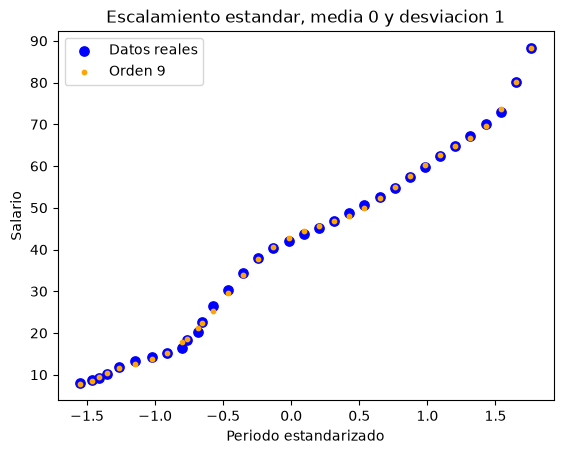

In [41]:
plt.scatter(X_v2_est, y2, s=45, color='blue', label='Datos reales')
plt.scatter(X_v2_est, lr9_2_est.predict(X9_2_est), s=10, color='orange', label='Orden 9')
plt.xlabel('Periodo estandarizado')
plt.ylabel('Salario')
plt.title('Escalamiento estandar, media 0 y desviacion 1')
plt.legend()
plt.show()